***Prepare Data***

In [1]:
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
from sklearn.linear_model import LinearRegression

**Import**

In [31]:
df = pd.read_csv("/workspaces/Machine-Learining-Models/day_001_linear_regression/data/insurance.csv")
df.head(10)

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520
5,31,female,25.740,0,no,southeast,3756.62160
6,46,female,33.440,1,no,southeast,8240.58960
7,37,female,27.740,3,no,northwest,7281.50560
8,37,male,29.830,2,no,northeast,6406.41070
9,60,female,25.840,0,no,northwest,28923.13692


Text(0.5, 1.0, 'Variables Relationships')

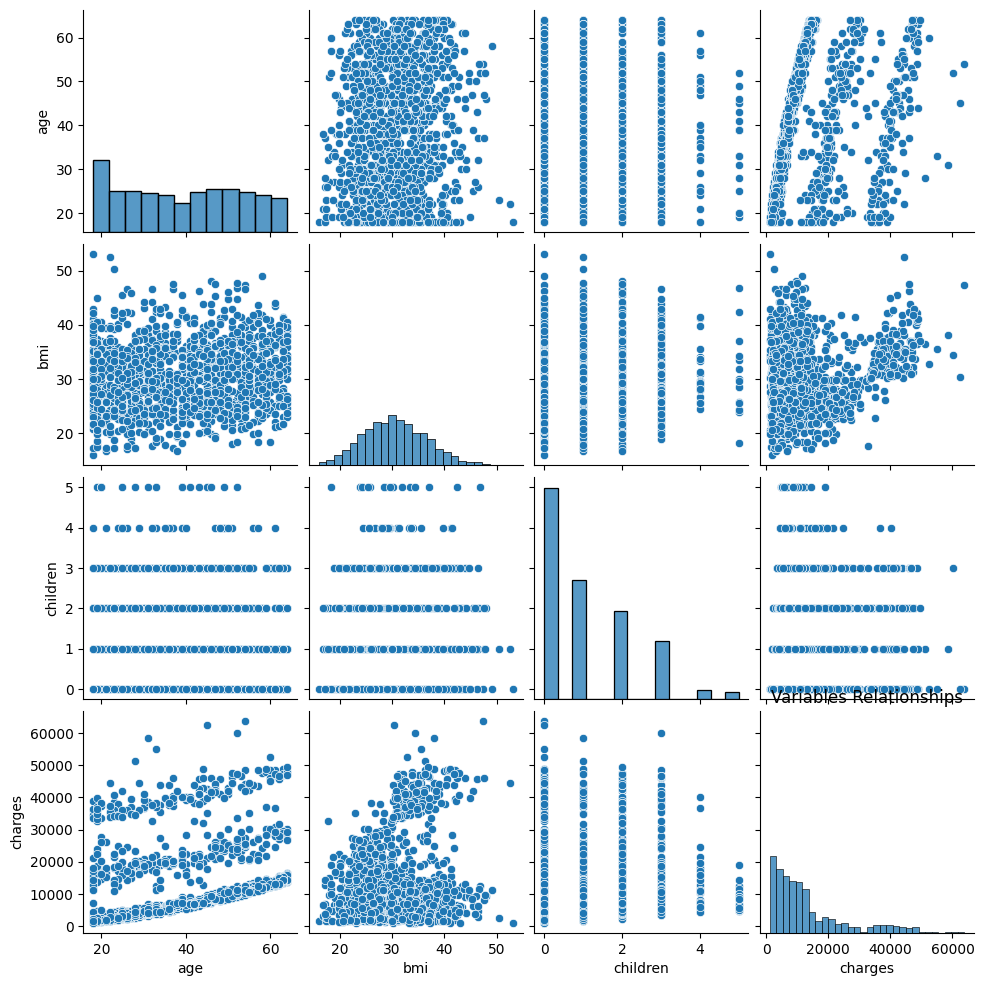

In [34]:
sns.pairplot(df, kind = "scatter")
plt.title("Variables Relationships")

**Explore**

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   str    
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   str    
 5   region    1338 non-null   str    
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), str(3)
memory usage: 73.3 KB


In [4]:
def wrangle(filepath):
    # load data
    df = pd.read_csv(filepath)
    
    # is_smoker: 1 if smoker, else 0
    df['is_smoker'] = (df['smoker'] == 'yes').astype(int)
    df['is_male'] = (df['sex'] == 'male').astype(int)
    # - bmi_smoker: bmi * is_smoker (interaction)
    df['bmi_smoker'] = df['is_smoker'] *df['bmi']
    # - age_smoker: age * is_smoker (interaction)
    df['bmi_smoker'] = df['is_smoker'] *df['age']

    # Drop the original categorical columns and 'children'
    df = df.drop(columns = ['sex', 'region', 'smoker', 'children'])

    # return the dataframe
    return df
    

In [5]:
df = wrangle("/workspaces/Machine-Learining-Models/day_001_linear_regression/data/insurance.csv")

In [6]:
df.head()

,age,bmi,charges,is_smoker,is_male,bmi_smoker
0,19,27.900,16884.92400,1,0,19
1,18,33.770,1725.55230,0,1,0
2,28,33.000,4449.46200,0,1,0
3,33,22.705,21984.47061,0,1,0
4,32,28.880,3866.85520,0,1,0


Text(0, 0.5, 'frequency')

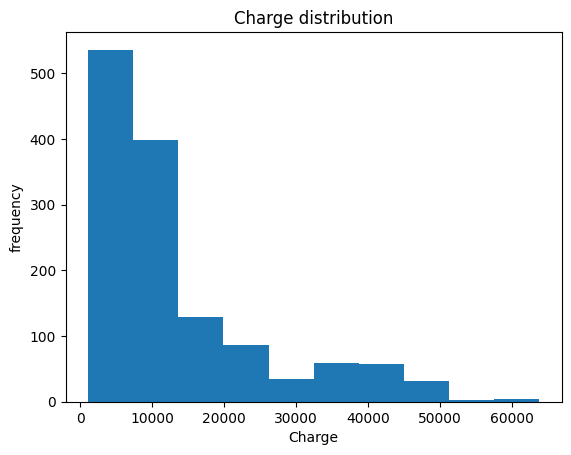

In [7]:
# the distribution of charges
plt.hist(df['charges'])
plt.title('Charge distribution')
plt.xlabel("Charge")
plt.ylabel('frequency')

**Split**

In [13]:
X = df[['age', 'bmi', 'is_smoker', 'is_male', 'bmi_smoker']]
y = df['charges']

X_train, X_test, y_train,y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

In [14]:
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("X_test shape:", X_test.shape)
print("y_test shape:", y_test.shape)

X_train shape: (1070, 5)
y_train shape: (1070,)
X_test shape: (268, 5)
y_test shape: (268,)


***Build MOdel***

**Baseline**

In [15]:
baseline_pred = y_train.mean()
baseline_arr = [baseline_pred] * len(y_train)
baseline_mae = mean_absolute_error(y_train, baseline_arr)
print(f'The baseline charge is : {baseline_pred}')
print(f' the baseline MAE: {baseline_mae}')

The baseline charge is : 13346.089736364485
 the baseline MAE: 9000.55612964432


**Iterate**

In [16]:
model = LinearRegression()

In [17]:
# fit the model
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [18]:
# make prediction usinf both dataseta
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

***Evaluate***

In [19]:
train_mae = mean_absolute_error(y_train, y_train_pred)
test_mae = mean_absolute_error(y_test, y_test_pred)

print(f"Training MAE: ${train_mae:,.2f}")
print(f"Test MAE:     ${test_mae:,.2f}")
print(f"improvement over baseline: ${(baseline_mae - test_mae) * 100/baseline_mae:,.2f} %")

Training MAE: $4,232.17
Test MAE:     $4,275.65
improvement over baseline: $52.50 %


Text(0.5, 1.0, 'Model Evaluation')

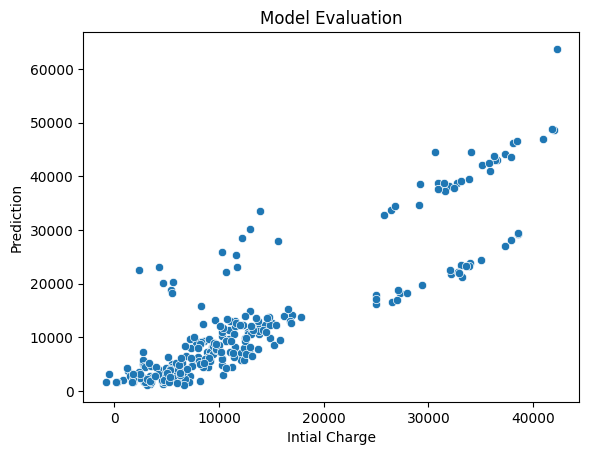

In [23]:
sns.scatterplot(x =y_test_pred, y=y_test)
plt.xlabel("Initial Charge")
plt.ylabel("Prediction")
plt.title("Model Evaluation")

In [26]:
residuals = y_test-y_test_pred
residuals

764       980.894533
887     -2207.920275
890     -9283.241895
1293      760.271465
259      7354.776900
            ...     
109      6066.548019
575       245.410042
535     -1246.662400
543     21510.034423
846     -2680.576093
Name: charges, Length: 268, dtype: float64

Text(0.5, 1.0, 'RESIDUAL')

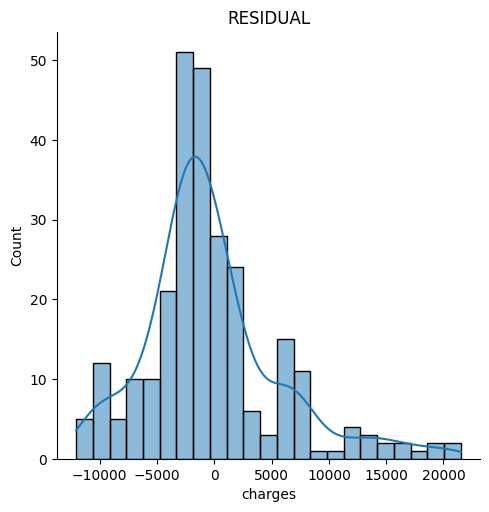

In [29]:
sns.displot(residuals, kde = True)
plt.title("RESIDUAL")

***Communicate Results***

In [49]:
def explain_model():
    
    # intercept and coefficients
    intercept = model.intercept_
    coefs = model.coef_
    feature_names = X_train.columns
    
    # model equation
    equation = f"charges = {intercept:.2f}"
    for name, coef in zip(feature_names, coefs):
        sign = "+" if coef >= 0 else "-"
        equation += f" {sign} {abs(coef):.2f} × {name}"
    print(equation)
    
    # Compare to baseline if provided
    if baseline_mae is not None:
        improvement = baseline_mae - test_mae
        pct_improvement = (improvement / baseline_mae) * 100
        print(f"Baseline MAE: ${baseline_mae:,.2f}")
        print(f"Improvement:  ${improvement:,.2f} ({pct_improvement:.1f}% better)")
explain_model()

charges = -11246.29 + 246.88 × age + 327.73 × bmi + 21333.67 × is_smoker - 6.24 × is_male + 61.17 × bmi_smoker
Baseline MAE: $9,000.56
Improvement:  $4,724.91 (52.5% better)


In [47]:
feature_names = X_train.columns
intercept = model.intercept_
coefs = model.coef_
test_mae = mean_absolute_error(y_test, model.predict(X_test))
r2 = model.score(X_test, y_test)

# Table 1: Coefficients
coef_df = pd.DataFrame({
    'Feature': ['Intercept'] + list(feature_names),
    'Coefficient': [intercept] + list(coefs)
})
coef_df['Impact'] = coef_df['Coefficient'].apply(
    lambda x: f"+${x:.2f}" if x >= 0 else f"-${abs(x):.2f}"
)
coef_df    

,Feature,Coefficient,Impact
0,Intercept,-11246.293356,-$11246.29
1,age,246.883418,+$246.88
2,bmi,327.734390,+$327.73
3,is_smoker,21333.668543,+$21333.67
4,is_male,-6.243652,-$6.24
5,bmi_smoker,61.174563,+$61.17
